In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Define tickers of US tech and finance stocks
tickers = ['AAPL', 'MSFT', 'GOOGL', 'JPM', 'BAC']

# Download adjusted closing prices (last 2 years)
data = yf.download(tickers, start='2023-01-01', end='2025-01-01')['Close']

print(data.head())

[                       0%                       ]

[*******************   40%                       ]  2 of 5 completed

[**********************60%****                   ]  3 of 5 completed

[**********************80%*************          ]  4 of 5 completed

[*********************100%***********************]  5 of 5 completed

Ticker            AAPL        BAC      GOOGL         JPM        MSFT
Date                                                                
2023-01-03  122.982704  30.800150  88.389473  124.292603  232.948288
2023-01-04  124.251183  31.379211  87.357986  125.451637  222.758362
2023-01-05  122.933540  31.314867  85.493401  125.423843  216.156296
2023-01-06  127.456772  31.627375  86.624039  127.823898  218.703781
2023-01-09  127.977943  31.149420  87.298470  127.295692  220.833145


In [3]:
# Compute daily percentage returns and drop missing values
returns = data.pct_change().dropna()

# Summary statistics: mean, std dev, min, max
print(returns.describe())

Ticker        AAPL         BAC       GOOGL         JPM        MSFT
count   501.000000  501.000000  501.000000  501.000000  501.000000
mean      0.001498    0.000775    0.001681    0.001347    0.001263
std       0.013452    0.015669    0.018404    0.013963    0.014286
min      -0.048167   -0.062039   -0.095094   -0.064678   -0.060528
25%      -0.006581   -0.008186   -0.008907   -0.005230   -0.006807
50%       0.001649    0.000000    0.003007    0.001895    0.001343
75%       0.008985    0.008678    0.011097    0.008124    0.009736
max       0.072649    0.084288    0.102244    0.115445    0.072435


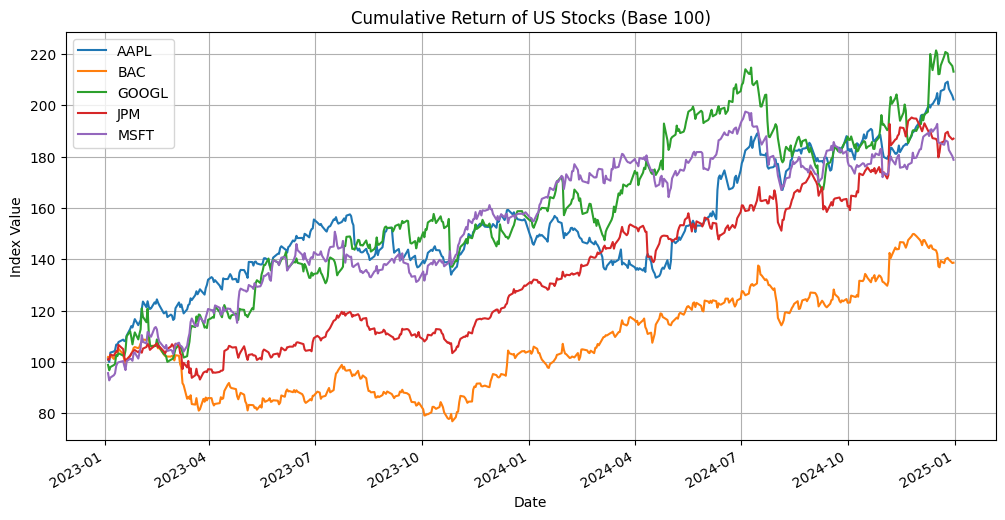

In [4]:
# Normalize returns to base 100 for fair comparison
cumulative_returns = (1 + returns).cumprod() * 100

# Plot cumulative performance
cumulative_returns.plot(figsize=(12, 6))
plt.title('Cumulative Return of US Stocks (Base 100)')
plt.ylabel('Index Value')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.savefig('cumulative_returns.png', dpi=150)
plt.show()

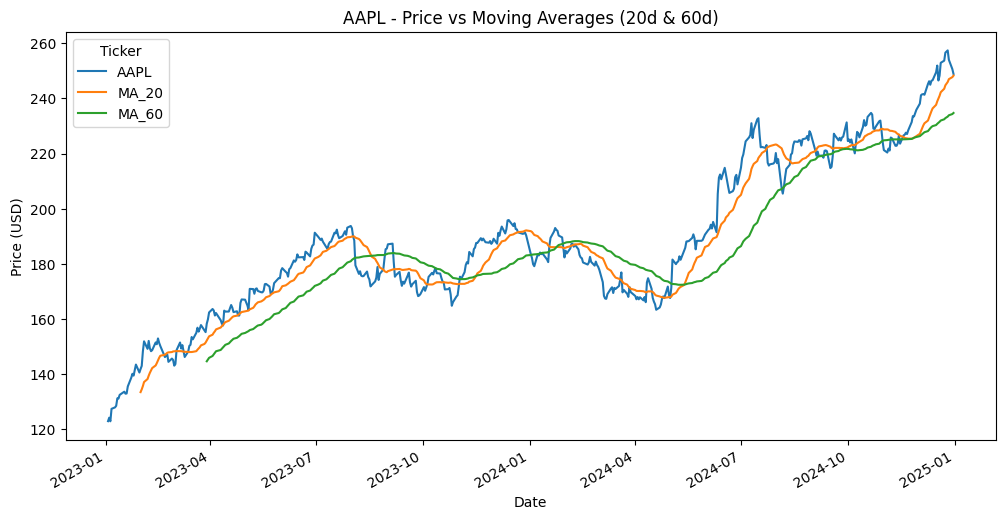

In [5]:
# Create DataFrame with AAPL price and moving averages
aapl = data[['AAPL']].copy()
aapl['MA_20'] = aapl['AAPL'].rolling(window=20).mean()   # Short-term trend
aapl['MA_60'] = aapl['AAPL'].rolling(window=60).mean()   # Long-term trend

aapl.plot(figsize=(12, 6))
plt.title('AAPL - Price vs Moving Averages (20d & 60d)')
plt.ylabel('Price (USD)')
plt.savefig('moving_averages.png', dpi=150)
plt.show()

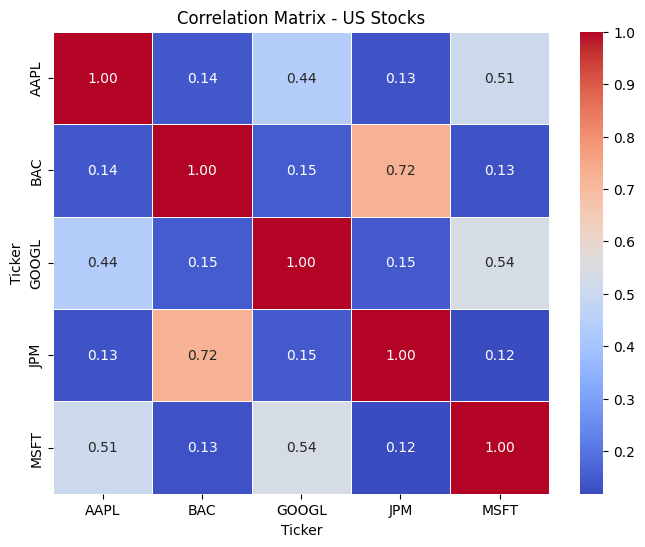

In [6]:
# Calculate correlation matrix between all assets
correlation = returns.corr()

# Plot heatmap to visualize diversification potential
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix - US Stocks')
plt.savefig('correlation_matrix.png', dpi=150)
plt.show()

In [7]:
# Annualize returns and volatility (252 trading days)
summary = pd.DataFrame({
    'Annual Return (%)': (returns.mean() * 252 * 100).round(2),
    'Annual Volatility (%)': (returns.std() * (252 ** 0.5) * 100).round(2),
    'Sharpe Ratio': ((returns.mean() * 252) / (returns.std() * (252 ** 0.5))).round(2)
})

print(summary.sort_values('Sharpe Ratio', ascending=False))
summary.to_csv('risk_return_summary.csv')

        Annual Return (%)  Annual Volatility (%)  Sharpe Ratio
Ticker                                                        
AAPL                37.74                  21.35          1.77
JPM                 33.96                  22.17          1.53
GOOGL               42.36                  29.21          1.45
MSFT                31.82                  22.68          1.40
BAC                 19.53                  24.87          0.79
